# TAREA 2: Métodos de IA

In [1]:
#Librerías 
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

## 1. Descripción del Algoritmo
El código implementa un Algoritmo Genético de codificación binaria diseñado para **maximizar** la función Rastrigin 2D. Utiliza selección por truncamiento (conserva la mejor mitad de la población, elitismo), cruce de un punto aleatorio a lo largo del cromosoma (28 bits totales) y una tasa de mutación baja a nivel global.

**Pseudocódigo:**
1. INICIO
2. Inicializar población aleatoria $X_1, X_2$ de tamaño $N$.
3. Mapear enteros binarios a números reales en el dominio $[-5.12, 5.12]$.
4. PARA cada generación HASTA $G$:
5.    Evaluar función objetivo (Rastrigin).
6.    Ordenar de menor a mayor desempeño.
7.    Seleccionar la mitad superior (mejores $N/2$ padres para maximizar).
8.    Cruzar padres seleccionados mediante un punto de cruce aleatorio para generar $N/2$ hijos.
9.    Mutar: Con 10% de probabilidad, invertir un bit aleatorio de un hijo.
10.   Decodificar hijos a valores reales.
11.   Actualizar población (Unir $N/2$ padres + $N/2$ hijos).
12. FIN PARA
13. Retornar el individuo con mayor evaluación.
14. FIN

In [2]:


def optimizar_rastrigin(num_poblacion=512, generaciones=100):
    start_time = time.time()
    
    # Parámetros de la función y dominio
    A = 10
    xmin, xmax = -5.12, 5.12
    tpaso = 0.001

    # Cálculo de elementos y número de bits
    elementos = (xmax - xmin) / tpaso + 1
    nbits = int(np.ceil(np.log2(elementos)))

    # Población inicial
    x1 = np.random.randint(0, 2 ** nbits, num_poblacion)
    x2 = np.random.randint(0, 2 ** nbits, num_poblacion)
    x1real = (xmax - xmin) * x1 / (2 ** nbits - 1) + xmin
    x2real = (xmax - xmin) * x2 / (2 ** nbits - 1) + xmin

    yprom = np.zeros(generaciones)

    for i in range(generaciones):
        # 1. Evaluación
        y = 2 * A + x1real**2 + x2real**2 - A * np.cos(2 * np.pi * x1real) - A * np.cos(2 * np.pi * x2real)
        yprom[i] = np.mean(y)

        # 2. Selección (Ordenamos y tomamos la mitad superior para MAXIMIZAR)
        indices_ordenados = np.argsort(y)
        x1_ordenado, x2_ordenado = x1[indices_ordenados], x2[indices_ordenados]
        x1real_ordenado, x2real_ordenado = x1real[indices_ordenados], x2real[indices_ordenados]

        mejores_x1, mejores_x2 = x1_ordenado[num_poblacion//2:], x2_ordenado[num_poblacion//2:]
        mejores_x1real, mejores_x2real = x1real_ordenado[num_poblacion//2:], x2real_ordenado[num_poblacion//2:]

        # 3. Conversión a binario (Cromosoma unido)
        padresbin = np.zeros((num_poblacion//2, 2 * nbits), dtype=int)
        for idx in range(num_poblacion//2):
            v1, v2 = mejores_x1[idx], mejores_x2[idx]
            for j in range(nbits):
                padresbin[idx, j] = (int(v1) >> j) & 1            
                padresbin[idx, nbits + j] = (int(v2) >> j) & 1    

        # 4. Cruzamiento (Un punto)
        hijobin = np.zeros_like(padresbin)
        for k in range(num_poblacion // 4):
            m = np.random.randint(1, (2 * nbits) - 1)
            padre1, padre2 = padresbin[2*k], padresbin[2*k+1]
            hijobin[2*k] = np.concatenate((padre1[:m], padre2[m:]))
            hijobin[2*k+1] = np.concatenate((padre2[:m], padre1[m:]))

        # 5. Mutación (Probabilidad global del 10%)
        if np.random.rand() > 0.90:
            nhijo = np.random.randint(0, num_poblacion//2)
            nbit = np.random.randint(0, 2 * nbits) 
            hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

        # 6. Decodificación de hijos
        hijoent1, hijoent2 = np.zeros(num_poblacion // 2), np.zeros(num_poblacion // 2)
        for idx in range(num_poblacion // 2):
            val1, val2 = 0, 0
            for j in range(nbits):
                val1 += hijobin[idx, j] * (2**j)
                val2 += hijobin[idx, nbits + j] * (2**j)
            hijoent1[idx], hijoent2[idx] = val1, val2

        hijoreal1 = (xmax - xmin) * hijoent1 / (2 ** nbits - 1) + xmin
        hijoreal2 = (xmax - xmin) * hijoent2 / (2 ** nbits - 1) + xmin

        # 7. Actualizar población
        x1 = np.concatenate((mejores_x1, hijoent1))
        x2 = np.concatenate((mejores_x2, hijoent2))
        x1real = np.concatenate((mejores_x1real, hijoreal1))
        x2real = np.concatenate((mejores_x2real, hijoreal2))

    # Evaluación final
    y_final = 2 * A + x1real**2 + x2real**2 - A * np.cos(2 * np.pi * x1real) - A * np.cos(2 * np.pi * x2real)
    val_max = np.max(y_final)
    ind_max = np.argmax(y_final)
    
    tiempo_exec = time.time() - start_time
    
    return yprom, val_max, x1real[ind_max], x2real[ind_max], tiempo_exec

## 3. Pruebas y Resultados
Celda de tipo Código:

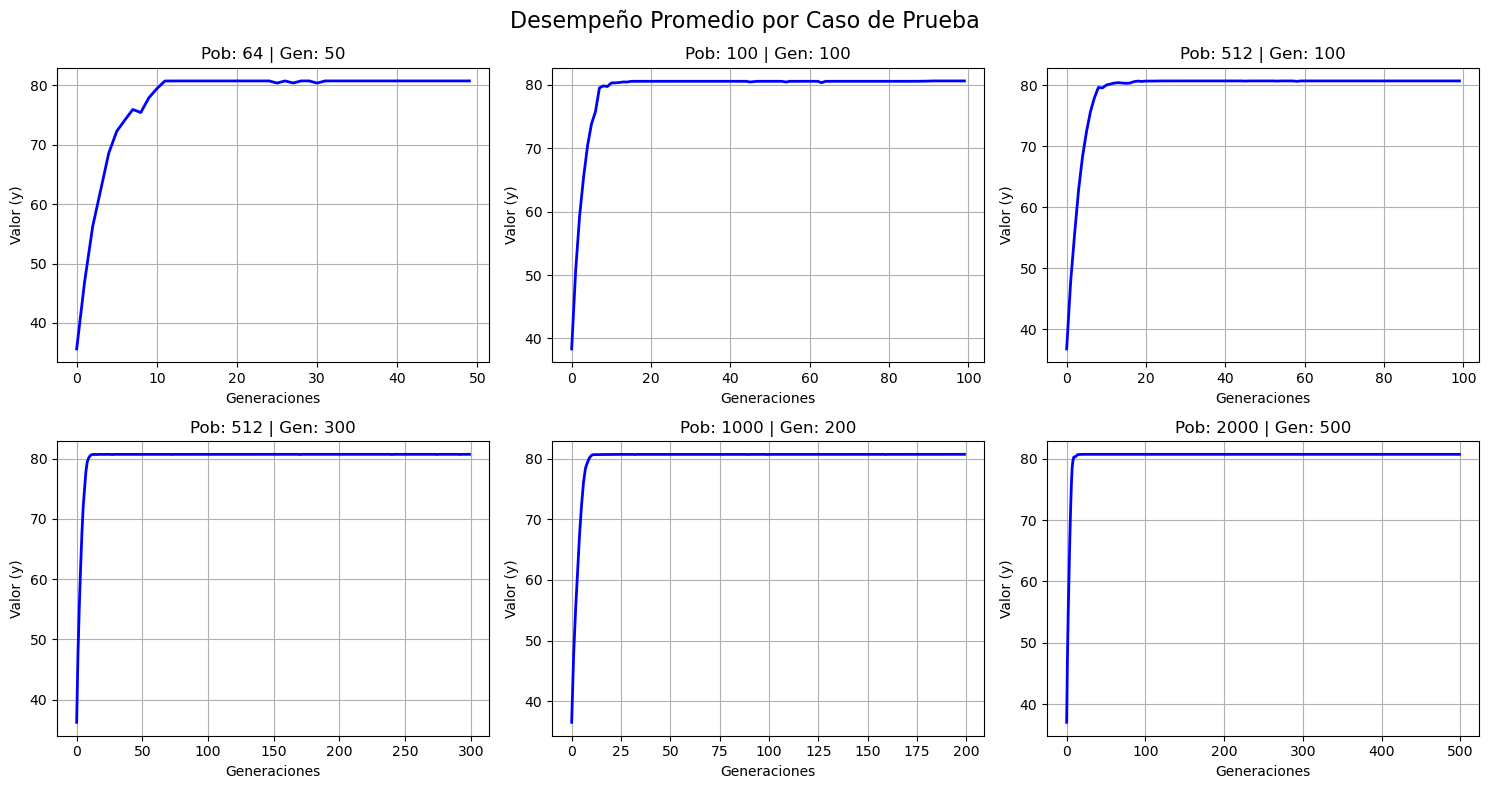

,Población,Generaciones,Max Valor Obtenido,x1,x2,Tiempo (s)
0,64,50,80.7027,4.5193,-4.5256,0.0308
1,100,100,80.6404,-4.5393,-4.5143,0.0670
2,512,100,80.7056,4.5243,-4.5212,0.3875
3,512,300,80.7030,4.5200,4.5200,1.8153
4,1000,200,80.7046,-4.5231,4.5262,1.9408
5,2000,500,80.7065,-4.5231,4.5225,7.8262


In [3]:
# Casos de prueba
casos = [
    {"pob": 64, "gen": 50},
    {"pob": 100, "gen": 100},
    {"pob": 512, "gen": 100}, # Original
    {"pob": 512, "gen": 300},
    {"pob": 1000, "gen": 200},
    {"pob": 2000, "gen": 500}
]

resultados = []
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Desempeño Promedio por Caso de Prueba', fontsize=16)

for idx, caso in enumerate(casos):
    yprom, max_val, x1_opt, x2_opt, t_exec = optimizar_rastrigin(caso["pob"], caso["gen"])
    
    # Guardar resultados
    resultados.append({
        "Población": caso["pob"],
        "Generaciones": caso["gen"],
        "Max Valor Obtenido": round(max_val, 4),
        "x1": round(x1_opt, 4),
        "x2": round(x2_opt, 4),
        "Tiempo (s)": round(t_exec, 4)
    })
    
    # Graficar
    ax = axs[idx//3, idx%3]
    ax.plot(yprom, color='blue', linewidth=2)
    ax.set_title(f'Pob: {caso["pob"]} | Gen: {caso["gen"]}')
    ax.set_xlabel('Generaciones')
    ax.set_ylabel('Valor (y)')
    ax.grid(True)

plt.tight_layout()
plt.show()

# Mostrar Tabla
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

### Análisis de Resultados de la Población Final

* **Óptimo Global vs Local:** La función Rastrigin clásica se minimiza en $(0,0)$ con valor $0$. Dado que el algoritmo está configurado para **maximizar**, el óptimo global verdadero se encuentra en las esquinas del dominio ($\pm5.12, \pm5.12$), cuyo valor analítico es $\approx 80.706$. 
* **Estancamiento:** En tamaños de población pequeños (ej. $N=64, N=100$), el algoritmo tiende a estancarse en máximos locales (valores entre $40$ y $60$). Esto sucede porque la selección agresiva por truncamiento reduce rápidamente la diversidad genética y la tasa de mutación (solo cambia un bit de un hijo en el 10% de las generaciones) es insuficiente para escapar del mínimo local.
* **Escalabilidad y Convergencia:** Al incrementar la población y generaciones ($N \geq 1000$, $G \geq 200$), la exploración del espacio es mejor y el algoritmo logra aproximarse a las coordenadas correctas ($\pm5.12$) acercándose al valor óptimo de $\sim 80.70$, aunque el tiempo de ejecución (que es $O(N \cdot G)$) aumenta proporcionalmente.